# PART A - Transform Demo

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.formula.api as smf

from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

In [10]:
# Load model-ready data #

DATA_PATH = Path("MasterPanel_prelim_cleaned_2016_2024.csv")
df = pd.read_csv(DATA_PATH)

if "date" not in df.columns:
    df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str).str.zfill(2) + "-01")
else:
    df["date"] = pd.to_datetime(df["date"])

print("Shape:", df.shape)
display(df.head())

Shape: (5184, 24)


,state,year,month,unemployment_rate,UPT,PostCOVID,VRM,StringencyIndex,GDP_billions,date,COVID_Emergency,Post_Emergency,regime,COVID_PolicyPeriod,Stringency_effective,is_red,GDP_billions_x_COVID_Emergency,GDP_billions_x_Post_Emergency,unemployment_rate_x_COVID_Emergency,unemployment_rate_x_Post_Emergency,VRM_x_COVID_Emergency,VRM_x_Post_Emergency,is_red_x_COVID_Emergency,is_red_x_Post_Emergency
0,Alabama,2016,1,6.3,427880.0,0,469390.0,NaN,211.14,2016-01-01,0,0,Pre-COVID (2016–2019),0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Alabama,2016,2,6.2,442620.0,0,478792.0,NaN,211.14,2016-02-01,0,0,Pre-COVID (2016–2019),0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Alabama,2016,3,5.9,457598.0,0,518498.0,NaN,211.14,2016-03-01,0,0,Pre-COVID (2016–2019),0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Alabama,2016,4,5.4,452035.0,0,493900.0,NaN,212.80,2016-04-01,0,0,Pre-COVID (2016–2019),0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Alabama,2016,5,5.3,435872.0,0,490068.0,NaN,212.80,2016-05-01,0,0,Pre-COVID (2016–2019),0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
# Create log1p versions #

# log1p(x) = log(1+x) (safe for zeros)
df["ln_UPT"] = np.log1p(df["UPT"])

for col in ["GDP_billions", "VRM", "unemployment_rate"]:
    df[f"ln_{col}"] = np.log1p(df[col])

# Quick sanity
display(df[["UPT", "ln_UPT", "GDP_billions", "ln_GDP_billions", "VRM", "ln_VRM", "unemployment_rate", "ln_unemployment_rate"]].head())


,UPT,ln_UPT,GDP_billions,ln_GDP_billions,VRM,ln_VRM,unemployment_rate,ln_unemployment_rate
0,427880.0,12.966600,211.14,5.357246,469390.0,13.059191,6.3,1.987874
1,442620.0,13.000469,211.14,5.357246,478792.0,13.079024,6.2,1.974081
2,457598.0,13.033749,211.14,5.357246,518498.0,13.158693,5.9,1.931521
3,452035.0,13.021517,212.80,5.365041,493900.0,13.110090,5.4,1.856298
4,435872.0,12.985106,212.80,5.365041,490068.0,13.102301,5.3,1.840550


In [12]:
#Utility plotting functions

def scatter_by_regime(data, x, y, regime_col="regime", sample=15000, title=None):
    tmp = data[[x, y, regime_col]].dropna()
    if len(tmp) > sample:
        tmp = tmp.sample(sample, random_state=42)

    plt.figure(figsize=(8, 6))
    for r in tmp[regime_col].unique():
        sub = tmp[tmp[regime_col] == r]
        plt.scatter(sub[x], sub[y], alpha=0.25, label=r)

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title if title else f"{y} vs {x} by Regime")
    plt.legend()
    plt.tight_layout()
    plt.show()

def quick_shape_stats(series):
    s = series.dropna()
    return {
        "n": len(s),
        "skew": float(pd.Series(s).skew()),
        "kurtosis_excess": float(pd.Series(s).kurt()),
        "min": float(s.min()),
        "max": float(s.max())
    }


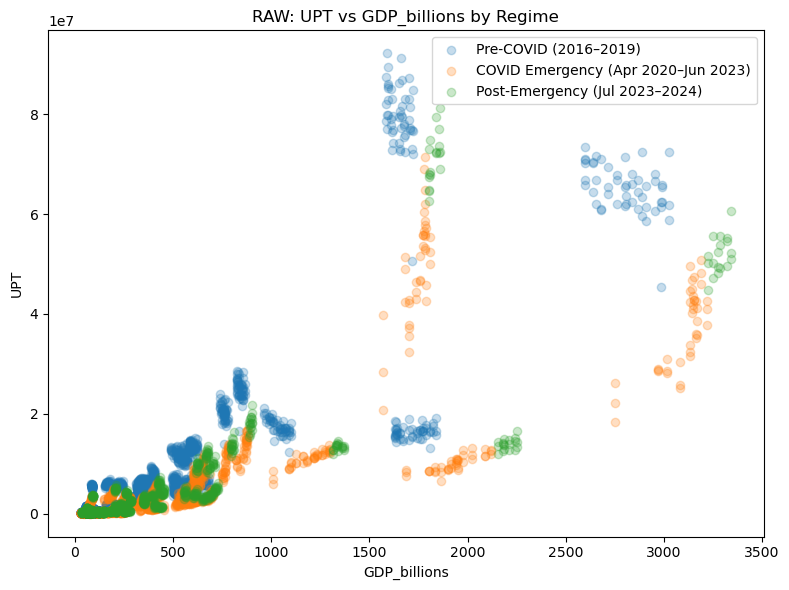

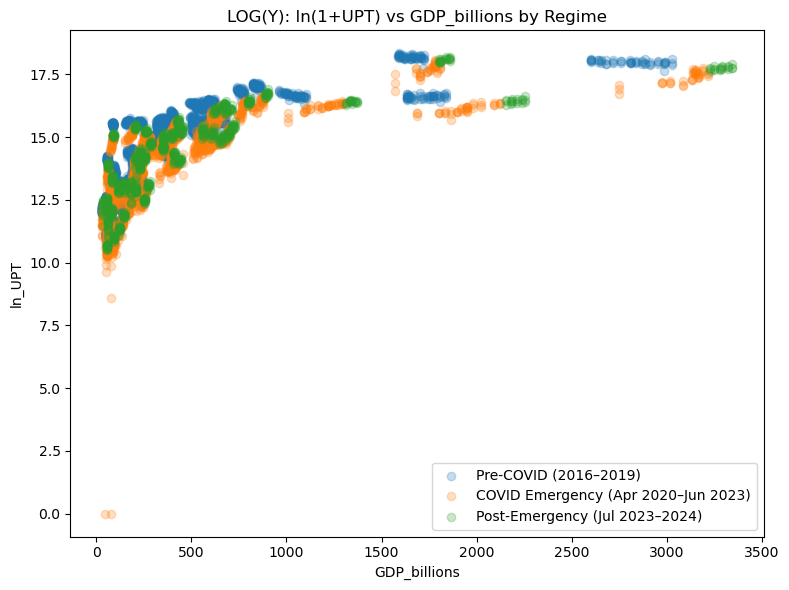

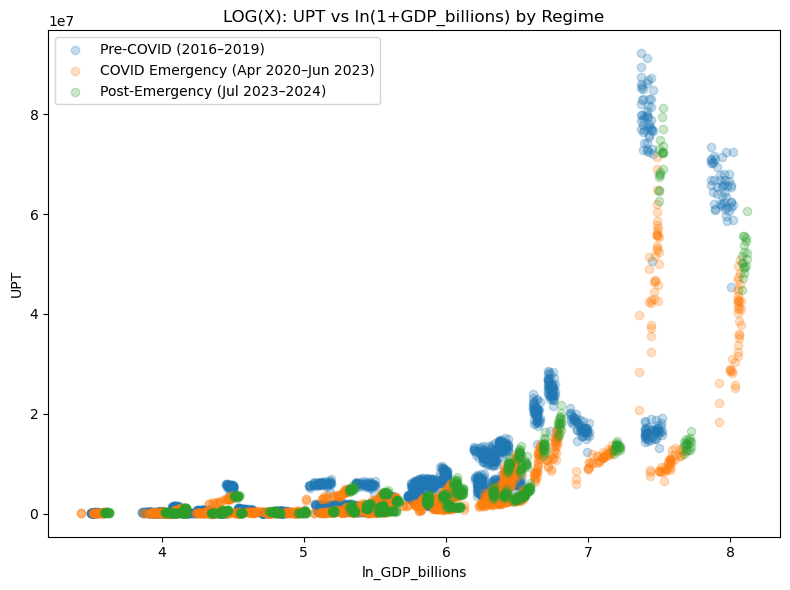

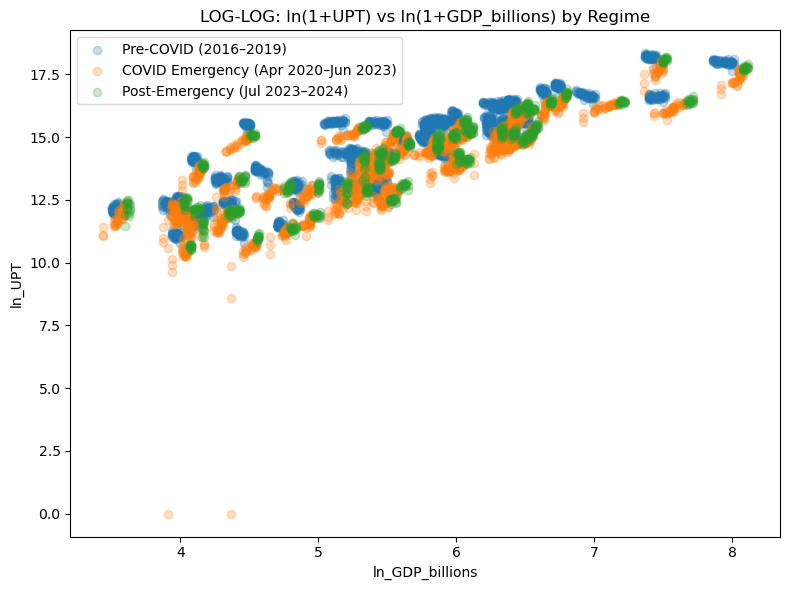

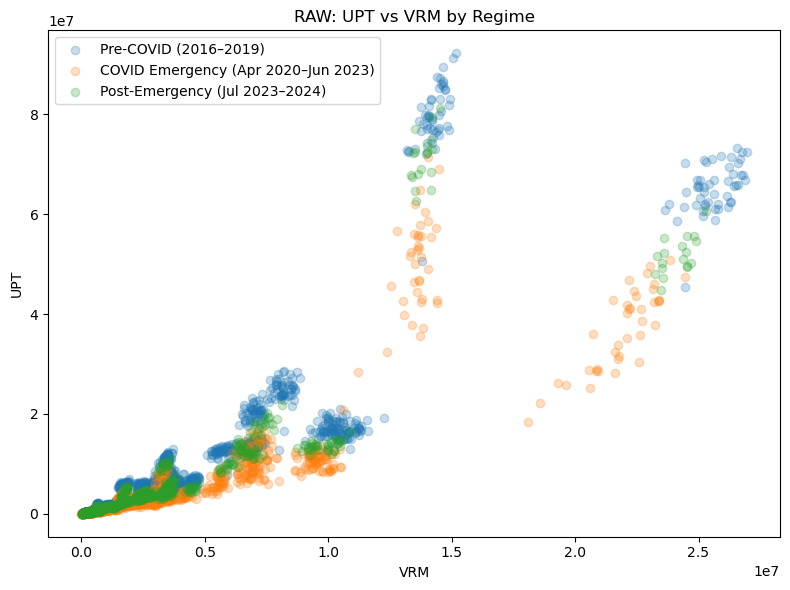

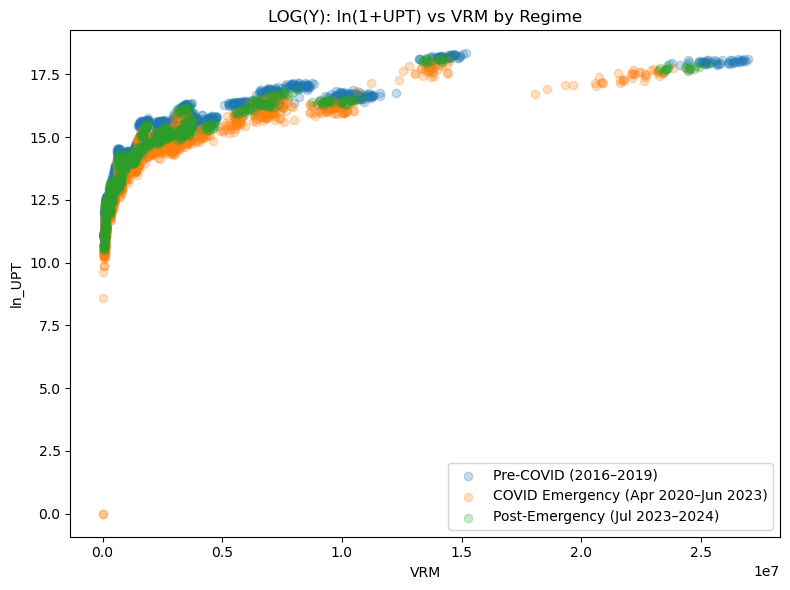

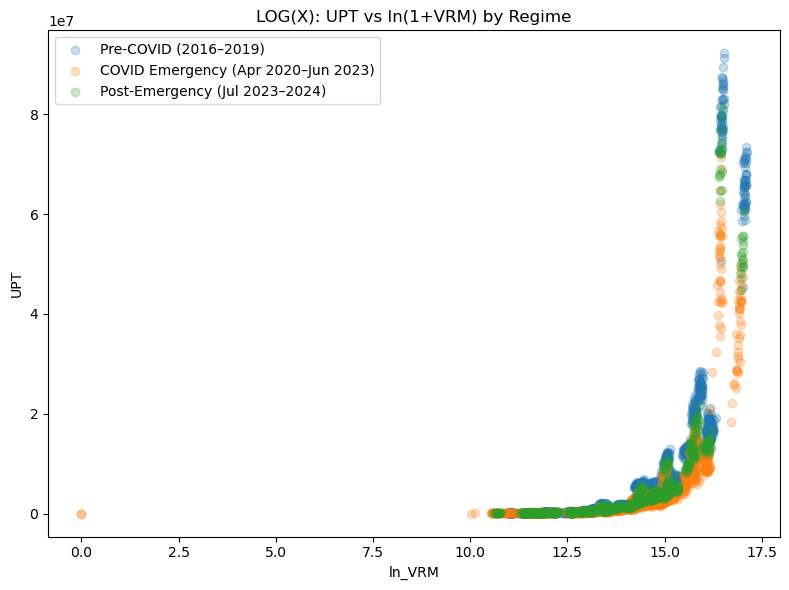

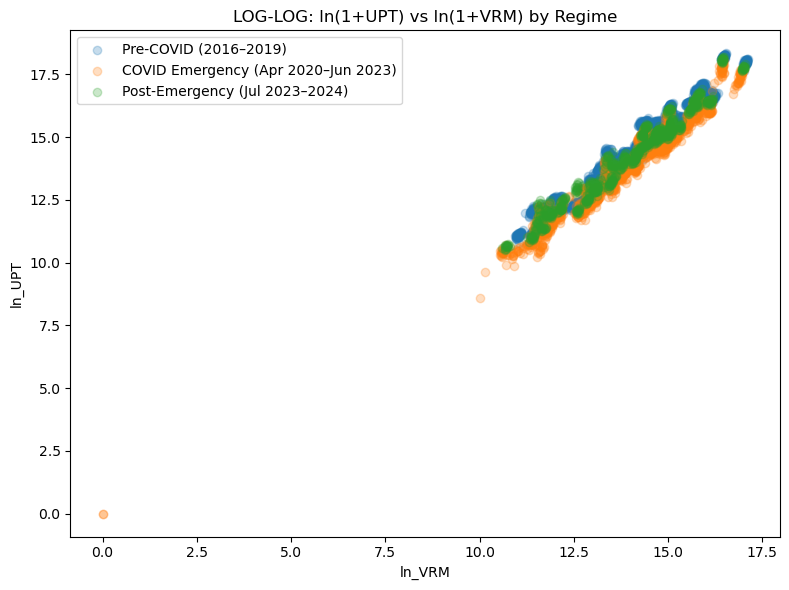

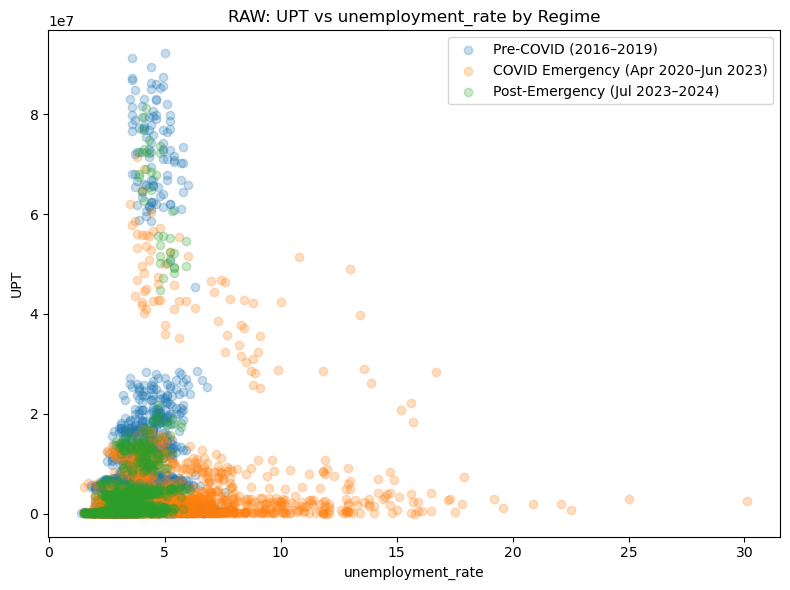

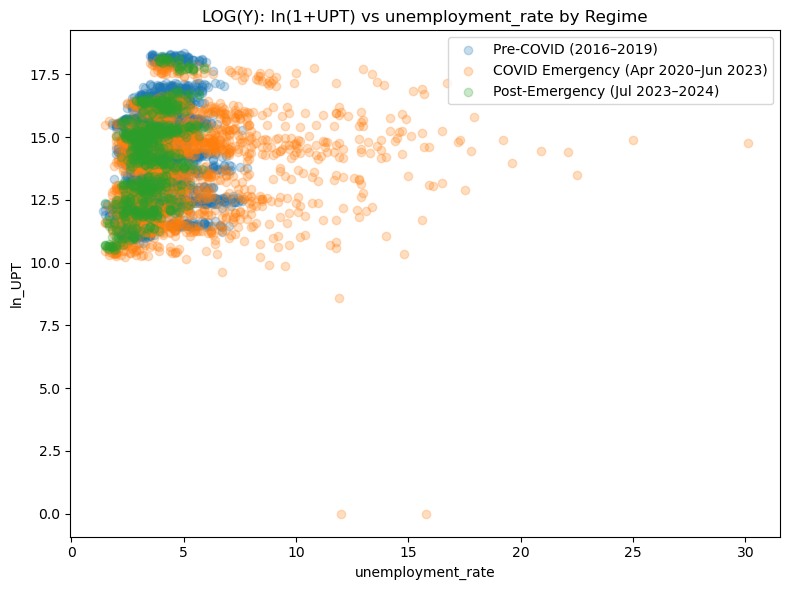

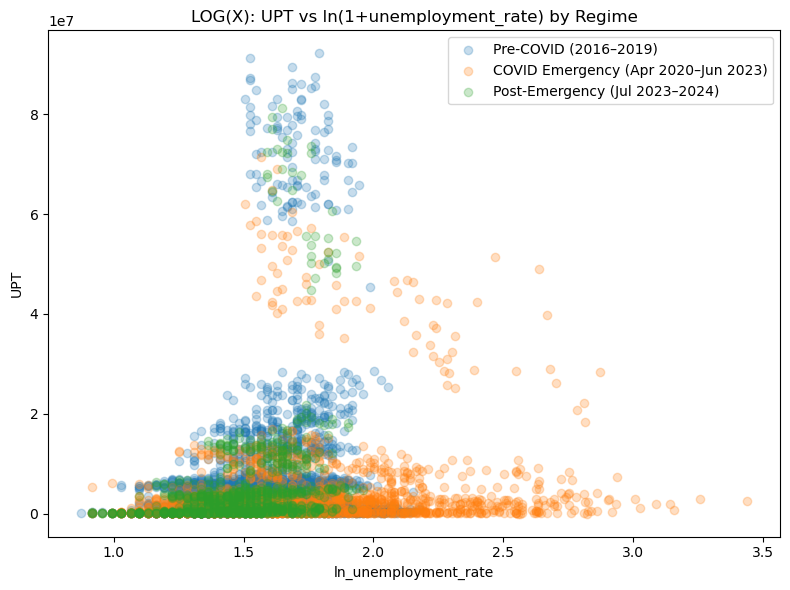

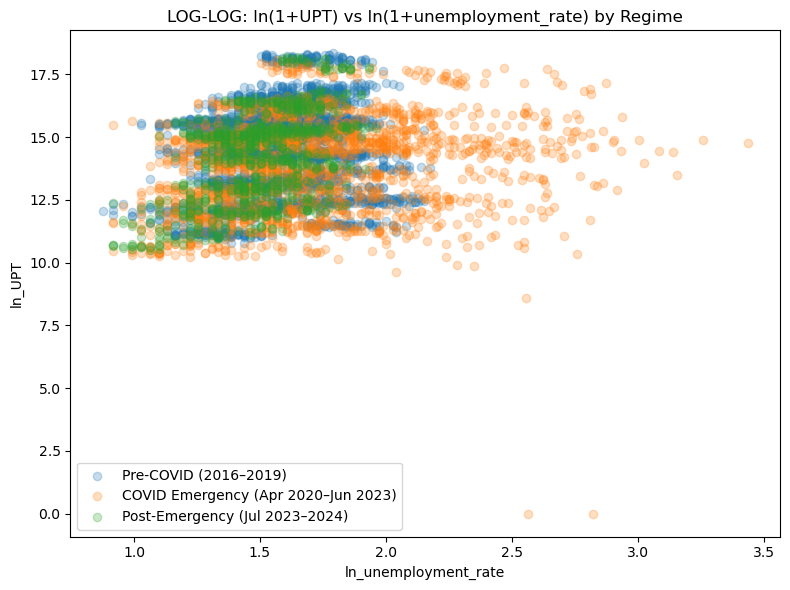

=== Shape diagnostics (raw vs log1p) ===


,variable,version,n,skew,kurtosis_excess,min,max
3,GDP_billions,log1p,5184,0.142051,-0.516355,3.435921,8.114582e+00
2,GDP_billions,raw,5184,2.988085,10.280942,30.060000,3.341860e+03
1,UPT,log1p,5184,-0.270227,0.629469,0.000000,1.833982e+01
0,UPT,raw,5184,4.105111,18.198137,0.000000,9.223221e+07
7,VRM,log1p,5184,-0.516279,1.941574,0.000000,1.710965e+01
6,VRM,raw,5184,3.036337,11.077166,0.000000,2.695411e+07
11,unemployment_rate,log1p,5184,1.090285,2.686625,0.875469,3.437208e+00
10,unemployment_rate,raw,5184,3.329656,19.226770,1.400000,3.010000e+01


Saved: Transform_Demo_ShapeStats.csv


In [13]:
# Transform Demo (Raw vs log variants)

X_LIST = ["GDP_billions", "VRM", "unemployment_rate"]

demo_rows = []

for x in X_LIST:
    # 1) Raw Y vs Raw X
    scatter_by_regime(df, x=x, y="UPT",
                      title=f"RAW: UPT vs {x} by Regime")

    # 2) Log(Y) vs Raw X
    scatter_by_regime(df, x=x, y="ln_UPT",
                      title=f"LOG(Y): ln(1+UPT) vs {x} by Regime")

    # 3) Raw Y vs Log(X)
    scatter_by_regime(df, x=f"ln_{x}", y="UPT",
                      title=f"LOG(X): UPT vs ln(1+{x}) by Regime")

    # 4) Log(Y) vs Log(X)
    scatter_by_regime(df, x=f"ln_{x}", y="ln_UPT",
                      title=f"LOG-LOG: ln(1+UPT) vs ln(1+{x}) by Regime")

    # Collect distribution shape stats (raw vs logged)
    demo_rows.append({
        "variable": "UPT",
        "version": "raw",
        **quick_shape_stats(df["UPT"])
    })
    demo_rows.append({
        "variable": "UPT",
        "version": "log1p",
        **quick_shape_stats(df["ln_UPT"])
    })
    demo_rows.append({
        "variable": x,
        "version": "raw",
        **quick_shape_stats(df[x])
    })
    demo_rows.append({
        "variable": x,
        "version": "log1p",
        **quick_shape_stats(df[f"ln_{x}"])
    })

demo_stats = pd.DataFrame(demo_rows).drop_duplicates(subset=["variable", "version"])
print("=== Shape diagnostics (raw vs log1p) ===")
display(demo_stats.sort_values(["variable", "version"]))

# Save for report traceability
demo_stats.to_csv("Transform_Demo_ShapeStats.csv", index=False)
print("Saved: Transform_Demo_ShapeStats.csv")

# PART B - Transformation Justification (Traceability + Metrics)

## Create log variables (if not already created)

In [14]:
df["ln_UPT"] = np.log1p(df["UPT"])
for col in ["GDP_billions", "VRM", "unemployment_rate"]:
    df[f"ln_{col}"] = np.log1p(df[col])


## Simple OLS and collect diagnostics

In [15]:
def run_ols_diagnostics(data: pd.DataFrame, y: str, x: str, max_shapiro_n=5000):
    tmp = data[[y, x]].dropna()
    n = len(tmp)
    if n < 50:
        return {"n": n, "r2": np.nan, "bp_p": np.nan, "shapiro_p": np.nan}

    X = sm.add_constant(tmp[x].astype(float))
    Y = tmp[y].astype(float)

    model = sm.OLS(Y, X).fit()
    resid = model.resid

    # Breusch–Pagan for heteroskedasticity
    bp = het_breuschpagan(resid, model.model.exog)
    bp_p = bp[1]

    # Shapiro on a sample of residuals (Shapiro is sensitive in large n; sample for practicality)
    sample_resid = resid.sample(min(n, max_shapiro_n), random_state=1)
    shapiro_p = stats.shapiro(sample_resid)[1] if len(sample_resid) >= 3 else np.nan

    return {"n": n, "r2": model.rsquared, "bp_p": bp_p, "shapiro_p": shapiro_p}

## Compare the 4 transform variants per predictor

In [16]:
X_LIST = ["GDP_billions", "VRM", "unemployment_rate"]

variants = [
    ("RAW",        "UPT",    "{x}"),
    ("LOG(Y)",     "ln_UPT", "{x}"),
    ("LOG(X)",     "UPT",    "ln_{x}"),
    ("LOG-LOG",    "ln_UPT", "ln_{x}")
]

rows = []

for x in X_LIST:
    for label, y_var, x_tpl in variants:
        x_var = x_tpl.format(x=x)
        if x_var not in df.columns or y_var not in df.columns:
            continue

        diag = run_ols_diagnostics(df, y=y_var, x=x_var)
        rows.append({
            "predictor": x,
            "variant": label,
            "y": y_var,
            "x": x_var,
            **diag
        })

results = pd.DataFrame(rows)

## Score variants
Goal:
   - Prefer higher BP p-value (less heteroskedasticity)
   - Prefer higher R² (secondary)
   - Shapiro p-value is noted, but not used as a strict requirement

In [17]:
def score_variant(row):
    score = 0
    # BP: higher p is better; reward if > 0.05, penalize if < 0.01
    if pd.notna(row["bp_p"]):
        if row["bp_p"] >= 0.05:
            score += 2
        elif row["bp_p"] < 0.01:
            score -= 2
        else:
            score += 0

    # R²: small weight (this is just a traceability demo)
    if pd.notna(row["r2"]):
        score += 0.5 * row["r2"]

    return score

results["score"] = results.apply(score_variant, axis=1)

print("=== Transform comparison results ===")
display(results.sort_values(["predictor", "score"], ascending=[True, False]))

=== Transform comparison results ===


,predictor,variant,y,x,n,r2,bp_p,shapiro_p,score
3,GDP_billions,LOG-LOG,ln_UPT,ln_GDP_billions,5184,0.719605,5.335418e-24,4.920057e-35,-1.640198
0,GDP_billions,RAW,UPT,GDP_billions,5184,0.640819,8.223373e-243,3.817991e-74,-1.679591
1,GDP_billions,LOG(Y),ln_UPT,GDP_billions,5184,0.478144,2.106937e-08,1.998644e-39,-1.760928
2,GDP_billions,LOG(X),UPT,ln_GDP_billions,5184,0.386880,5.739686e-132,1.706752e-71,-1.806560
7,VRM,LOG-LOG,ln_UPT,ln_VRM,5184,0.948339,7.693633e-03,2.930863e-17,-1.525830
4,VRM,RAW,UPT,VRM,5184,0.758624,1.787914e-197,1.037659e-78,-1.620688
5,VRM,LOG(Y),ln_UPT,VRM,5184,0.542563,1.017159e-22,1.235076e-46,-1.728718
6,VRM,LOG(X),UPT,ln_VRM,5184,0.347486,2.209964e-81,6.296715e-76,-1.826257
11,unemployment_rate,LOG-LOG,ln_UPT,ln_unemployment_rate,5184,0.031489,7.392156e-12,1.284923e-29,-1.984256
10,unemployment_rate,LOG(X),UPT,ln_unemployment_rate,5184,0.015844,9.579796e-09,1.365862e-79,-1.992078


## Pick a recommended variant per predictor

In [18]:
recommended = (
    results.sort_values(["predictor", "score"], ascending=[True, False])
           .groupby("predictor", as_index=False)
           .head(1)
           .rename(columns={"variant": "recommended_variant"})
)

print("=== Recommended transform variant per predictor (traceability) ===")
display(recommended[["predictor", "recommended_variant", "y", "x", "bp_p", "r2", "shapiro_p", "score"]])

# Save
results.to_csv("Transform_Comparison_AllVariants.csv", index=False)
recommended.to_csv("Transform_Recommendations.csv", index=False)
print("Saved: Transform_Comparison_AllVariants.csv, Transform_Recommendations.csv")

=== Recommended transform variant per predictor (traceability) ===


,predictor,recommended_variant,y,x,bp_p,r2,shapiro_p,score
3,GDP_billions,LOG-LOG,ln_UPT,ln_GDP_billions,5.335418e-24,0.719605,4.920057e-35,-1.640198
7,VRM,LOG-LOG,ln_UPT,ln_VRM,7.693633e-03,0.948339,2.930863e-17,-1.525830
11,unemployment_rate,LOG-LOG,ln_UPT,ln_unemployment_rate,7.392156e-12,0.031489,1.284923e-29,-1.984256


Saved: Transform_Comparison_AllVariants.csv, Transform_Recommendations.csv


## Apply final chosen transformations
Decision (based on EDA + interpretability):
   - DV: ln_UPT
   - GDP, VRM: ln(1 + X)
   - unemployment: keep level (unemployment_rate)

In [19]:
df["Y_final"] = df["ln_UPT"]
df["X_GDP_final"] = df["ln_GDP_billions"]
df["X_VRM_final"] = df["ln_VRM"]
df["X_UNEMP_final"] = df["unemployment_rate"]  # keep level (documented)

print("Final variables created:")
display(df[["Y_final", "X_GDP_final", "X_VRM_final", "X_UNEMP_final"]].head())

Final variables created:


,Y_final,X_GDP_final,X_VRM_final,X_UNEMP_final
0,12.966600,5.357246,13.059191,6.3
1,13.000469,5.357246,13.079024,6.2
2,13.033749,5.357246,13.158693,5.9
3,13.021517,5.365041,13.110090,5.4
4,12.985106,5.365041,13.102301,5.3


# Part C - H1 Panel FE Model (Structural break via interactions)
H1: The ridership–GDP relationship differs across regimes.  
 Specification (log DV):  
   ln_UPT_it = β0 + β1 ln_GDP_it  
              + β2 (ln_GDP_it × COVID_Emergency_t)  
              + β3 (ln_GDP_it × Post_Emergency_t)  
              + State FE + Time (year-month) FE + ε_it  
Inference:  
   Clustered SE by state

In [21]:
# -------------------------
# Ensure time FE id (year-month)
# -------------------------
df["ym"] = df["date"].dt.to_period("M").astype(str)

# -------------------------
# Final variables for H1
# -------------------------
# DV and key predictor (log-log)
df["ln_UPT"] = np.log1p(df["UPT"])
df["ln_GDP"] = np.log1p(df["GDP_billions"])

# Interaction terms
df["ln_GDP_x_COVID_Emergency"] = df["ln_GDP"] * df["COVID_Emergency"]
df["ln_GDP_x_Post_Emergency"] = df["ln_GDP"] * df["Post_Emergency"]

# -------------------------
# Model formula (State FE + Time FE)
# -------------------------
# C(state) = state fixed effects
# C(ym)    = year-month fixed effects
formula_h1 = """
ln_UPT ~ ln_GDP
       + ln_GDP:COVID_Emergency
       + ln_GDP:Post_Emergency
       + C(state)
       + C(ym)
"""

# -------------------------
# Fit model with clustered SE by state
# -------------------------
model_h1 = smf.ols(formula=formula_h1, data=df).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["state"]}
)

print(model_h1.summary())

# -------------------------
# Interpret key coefficients (marginal GDP effect by regime)
# -------------------------
b = model_h1.params

beta_pre = b.get("ln_GDP", np.nan)
beta_emg = beta_pre + b.get("ln_GDP:COVID_Emergency", 0.0)
beta_post = beta_pre + b.get("ln_GDP:Post_Emergency", 0.0)

print("\n=== Implied ln(GDP) effect on ln(UPT) by regime (approx elasticities) ===")
print(f"Pre-COVID:        {beta_pre:.4f}")
print(f"COVID Emergency:  {beta_emg:.4f}")
print(f"Post-Emergency:   {beta_post:.4f}")

# Optional: joint test that interaction terms are zero (no structural break)
# H0: ln_GDP:COVID_Emergency = 0 and ln_GDP:Post_Emergency = 0
ftest = model_h1.f_test("ln_GDP:COVID_Emergency = 0, ln_GDP:Post_Emergency = 0")
print("\n=== Joint test of structural break (GDP interactions) ===")
print(ftest)

                            OLS Regression Results                            
Dep. Variable:                 ln_UPT   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     189.8
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           1.87e-41
Time:                        20:42:21   Log-Likelihood:                -117.19
No. Observations:                5184   AIC:                             550.4
Df Residuals:                    5026   BIC:                             1586.
Df Model:                         157                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

C:\Users\jjvar\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 157, but rank is 47
  warnings.warn('covariance of constraints does not have full '
